In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'gpu'  # Use only GPU

from jax import value_and_grad,jit
import optax
import jax

# https://pypi.org/project/get-mnist/
from mnist import fashion_mnist

import jax.numpy as jnp
import numpy as np

from tqdm import tqdm

from matplotlib import pyplot as plt

In [3]:
jax.devices()

[CudaDevice(id=0)]

In [4]:
x, y, xtest, ytest = fashion_mnist()
y = y.astype(float)
ytest = ytest.astype(float)
x = x.reshape(x.shape[0],-1)
xtest = xtest.reshape(xtest.shape[0],-1)

# normalize
x = 2*x/255.0 - 1
xtest = 2*xtest/255.0 - 1

x.shape, x.min(), x.max()

[MNIST] Caching data at /home/sampad/.local/share/FASHION_MNIST
[MNIST] Found http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz in cache.
[MNIST] Found http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz in cache.
[MNIST] Found http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz in cache.
[MNIST] Found http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz in cache.


((60000, 784), np.float32(-1.0), np.float32(1.0))

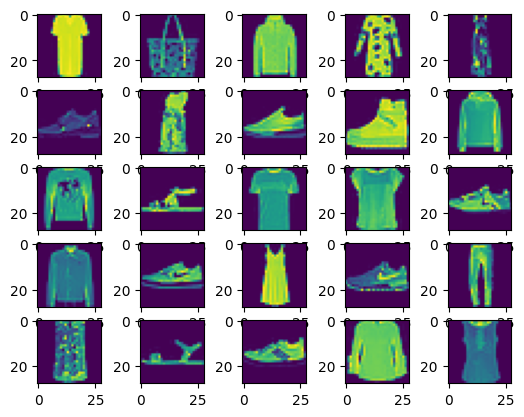

In [110]:
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x[np.random.randint(10_000)].reshape(28,28))

In [87]:
def gen(params, r):
    for p in params[:-1]:
        r = r @ p 
        r = jax.nn.relu(r)
    r = r @ params[-1]
    r = jax.nn.tanh(r)
    return r

def dis(params, x):
    for p in params[:-1]:
        x = x @ p 
        x = jax.nn.relu(x)
    x = x @ params[-1]
    x = jax.nn.sigmoid(x)
    return x

def gan(params, r, x, labels):
    gparams,dparams = params
    
    fake = gen(gparams, r)

    if type(x)!=type(None):
        real = x
        data = jnp.vstack([real, fake])
    else:
        data = fake 


    yhat = dis(dparams, data)

    # loss = jnp.mean( (yhat - labels)**2)
    loss = -jnp.mean(labels * jnp.log(yhat) + (1 - labels) * jnp.log(1 - yhat))
    return loss


dgan = jit(value_and_grad(gan))

In [88]:
# Initialize parameters with proper scaling
NOISE_DIM = 100
def xavier_init(input_dim, output_dim):
    scale = jnp.sqrt(2.0 / (input_dim + output_dim))
    return np.random.randn(input_dim, output_dim) * scale

# Initialize parameters with He initialization for ReLU
def he_init(input_dim, output_dim):
    scale = jnp.sqrt(2.0 / input_dim)
    return np.random.randn(input_dim, output_dim) * scale

params_init = he_init

gparams = [
    params_init(NOISE_DIM, 128),
    params_init(128, 256),
    params_init(256, 512),
    params_init(512, 784)
]

dparams = [
    params_init(784, 512),
    params_init(512, 256),
    params_init(256, 128),
    params_init(128, 1)
]

In [90]:
goptimizer = optax.adamw(learning_rate=1e-4)
doptimizer = optax.adamw(learning_rate=1e-4)

gstate = goptimizer.init(gparams)
dstate = doptimizer.init(dparams)

In [91]:

BSIZE = 1000
EPOCHS = 500


pbar  = tqdm(range(EPOCHS), colour="blue", ncols=100)

disloss, genloss = 0,0
for _ in pbar:
    random = np.random.randn(x.shape[0], NOISE_DIM)
    
    bids = range(0,x.shape[0],BSIZE)


    for bid in bids:
        xbatch = x[bid:bid+BSIZE]
        rbatch = random[bid:bid+BSIZE]

        ##################### TRAIN DISCRIMINATOR

        real_labels = np.ones(xbatch.shape[0]) * 0.9 # smooth the labels / label smoothing
        fake_labels = np.zeros( rbatch.shape[0]) + 0.1 # label smoothing
        
        
        labels = np.hstack([real_labels, fake_labels]).reshape(-1,1)
        #####################

        # train discriminator
        disloss, gradient = dgan([gparams, dparams], rbatch, xbatch, labels)
        dis_gradient = gradient[1]
        dupdates, dstate = doptimizer.update(dis_gradient, dstate, dparams)
        dparams = optax.apply_updates(dparams, dupdates)

        pbar.set_postfix_str(f"genloss: {genloss*100:.2f}% \t disloss: {disloss*100:.2f}%")

    if _ % 4 < 2: continue
        
    
    for bid in bids:
        xbatch = x[bid:bid+BSIZE]
        rbatch = random[bid:bid+BSIZE]

        #####################TRAIN GENERATOR 
        
        # WE DONT CARE ABOUT REAL IMAGES HERE
        # WE WANT FAKE IMAGES TO BE COUNTED AS REAL

        #real_labels = np.ones( xbatch.shape[0]) # not needed
        fake_labels = np.ones( rbatch.shape[0]).reshape(-1,1)
        
        labels = fake_labels
        #####################
        
        # train generator
        genloss, gradient = dgan([gparams, dparams], rbatch, None, labels)
        gen_gradient = gradient[0]
        gupdates, gstate = goptimizer.update(gen_gradient, gstate, gparams)
        gparams = optax.apply_updates(gparams, gupdates)
        
        pbar.set_postfix_str(f"genloss: {genloss*100:.2f}% \t disloss: {disloss*100:.2f}%")

        
    

100%|██████████████████████████| 500/500 [03:20<00:00,  2.50it/s, genloss: 40.01% 	 disloss: 35.58%]


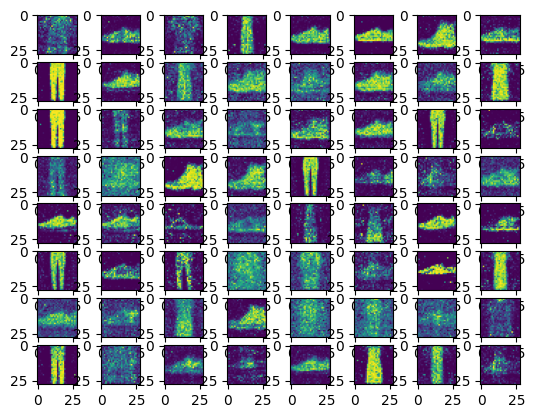

In [114]:
generated = gen(gparams, random)
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(generated[np.random.randint(10_000)].reshape(28,28))